# Final General Anxiety Disorder (GAD) data analysis
The NHIS data was collected by the CDC in America and the gaming data was primarily provided by 18-22 year olds, so the comparisons below follow those guidelines for a more equal comparison.

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from my_functions import visualize_count_plot, visualize_and_label_count_plot

conn = sqlite3.connect('../data/mentalhealth.db')

pd.set_option('display.max_columns', None)

## Set Global Variables

In [3]:
colors_ld=['#d7f0fa','#92c5de','#4393c3', '#2166ac', '#5e3c99', '#2d1e2f', '#0f0a14']
colors_dl=['#0f0a14', '#2d1e2f', '#5e3c99', '#2166ac', '#4393c3', '#92c5de', '#d7f0fa']

In [4]:
conn.execute("""
    CREATE TEMP VIEW gad_data_usa_18_22 AS
    SELECT
        p.participant_id,
        p.survey_id,
        p.sex_id,
        p.education_id,
        p.residence,
        p.age,
        p.region_id,
        r.GAD1,
        r.GAD2,
        r.GAD3,
        r.GAD4,
        r.GAD5,
        r.GAD6,
        r.GAD7,
        r.GAD_total,
        r.GAD_cat
    FROM participant p
    JOIN GAD_response r on r.participant_id = p.participant_id
    WHERE p.age BETWEEN 18 AND 22
""")

## How do the total GAD scores compare between gamers and the general population?
- Only USA data
- 18-22 years old
- Show categories on countplots

In [76]:
# I ended up not using this, but wanted to keep the work in the notebook.

# gamer_GAD_scores_percent_query = ("""
#     SELECT
#         GAD_total,
#         COUNT(*) as num_participants,
#         COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS percentage
#     FROM gad_data_usa_18_22
#     WHERE survey_id = 1 
#         AND GAD_total >0
#     GROUP BY GAD_total
#     ORDER BY GAD_total
# """)

# gamer_GAD_scores_percent_result = pd.read_sql(gamer_GAD_scores_percent_query, conn, index_col='GAD_total')['percentage']

# I got stuck figuring out how to make the result into a pandas.Series
# ChatGPT walked me through the logic to fix this and to convert the
# total to percentages. I knew I needed a window function, but got 
# stuck in the execution.

# visualize_count_plot(gamer_GAD_scores_percent_result, 'GAD Score', 'Percent of Participants', 'Gamer GAD scores')

In [88]:
gamer_GAD_scores_query = ("""
    SELECT
        g.GAD_total,
        g.GAD_cat,
        c.cat_name
    FROM gad_data_usa_18_22 g
    JOIN GAD_category c on c.GAD_cat = g.GAD_cat
    WHERE survey_id = 1
""")

gamer_GAD_scores_result = pd.read_sql(gamer_GAD_scores_query, conn)


nhis_GAD_scores_query = ("""
    SELECT
        g.GAD_total,
        g.GAD_cat,
        c.cat_name
    FROM gad_data_usa_18_22 g
    JOIN GAD_category c on c.GAD_cat = g.GAD_cat
    WHERE survey_id = 2
""")

nhis_GAD_scores_result = pd.read_sql(nhis_GAD_scores_query, conn)

In [126]:
def display_GAD_countplot(dataframe, label_y_align, plot_title):

    average_GAD = dataframe['GAD_total'].mean().round(1)

    plt.figure(figsize=(10,6))

    # This tells the palette how the categories should be colored
    palette_list = {
        'None/Minimal (0-4)': colors_ld[1],
        'Mild (5-9)': colors_ld[2],
        'Moderate (10-14)': colors_ld[3],
        'Severe (>15)': colors_ld[5]
    }

    ax = sns.countplot(
        x='GAD_total', 
        data = dataframe,
        hue = 'cat_name', 
            # hue tells the palette what column to use to know 
            # what category to use from the palette_list
        dodge=False,
        gap=-.25,
        palette = palette_list,
        edgecolor=colors_ld[-1]
    )

    # Remove extra lines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add average line
    ax.axvline(
        average_GAD,
        color="red",
        linewidth = 1,
        alpha = .7
    )

    ax.text(
        average_GAD+0.25,
        label_y_align,
        f"Avearage\nGAD score\n({average_GAD})",
        color="red",
        fontsize=10
    )

    # Customize xticks
    plt.xticks([0, 10, 20], [0, 10, 20])


    plt.legend(
        title='Anxiety Level', 
        loc='center right'
        )

    plt.title(plot_title, fontsize=18, pad=20)
    plt.xlabel("Generalized Anxiety Disorder (GAD) Assessment Score", fontsize=12)
    plt.ylabel("Number of Survey Participants", fontsize=12)

    plt.tight_layout()

    plt.show()

# References: 
#   1- https://stackoverflow.com/questions/59695334/custom-color-palette-in-seaborn
#   2- I got very close, but needed help understanding how 'hue', 'dodge', and 'gap'worked: ChatGPT helped
#   3- https://www.geeksforgeeks.org/python/how-to-adjust-number-of-ticks-in-seaborn-plots/ 

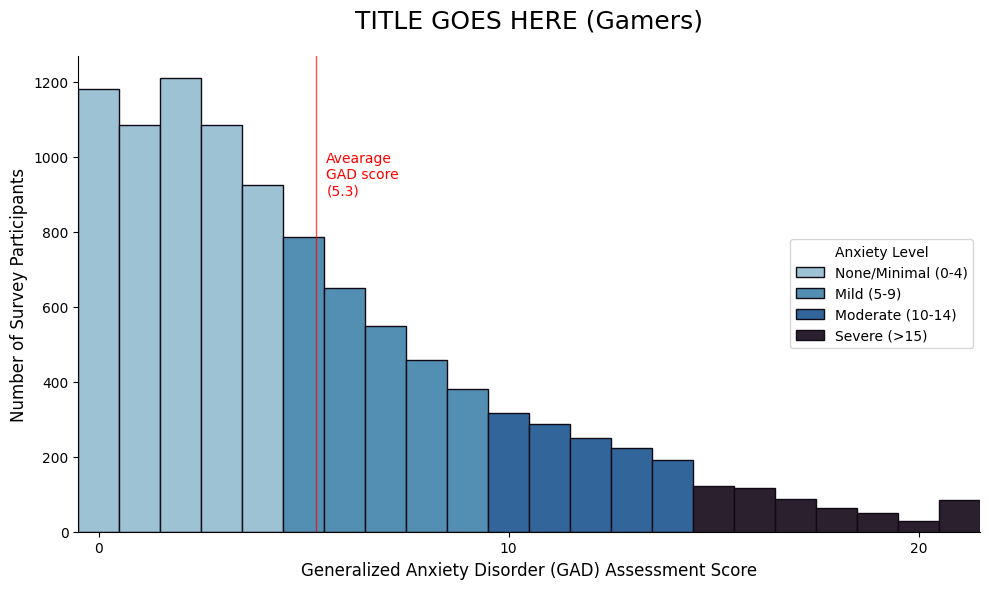

In [127]:
display_GAD_countplot(gamer_GAD_scores_result, 900, 'TITLE GOES HERE (Gamers)')

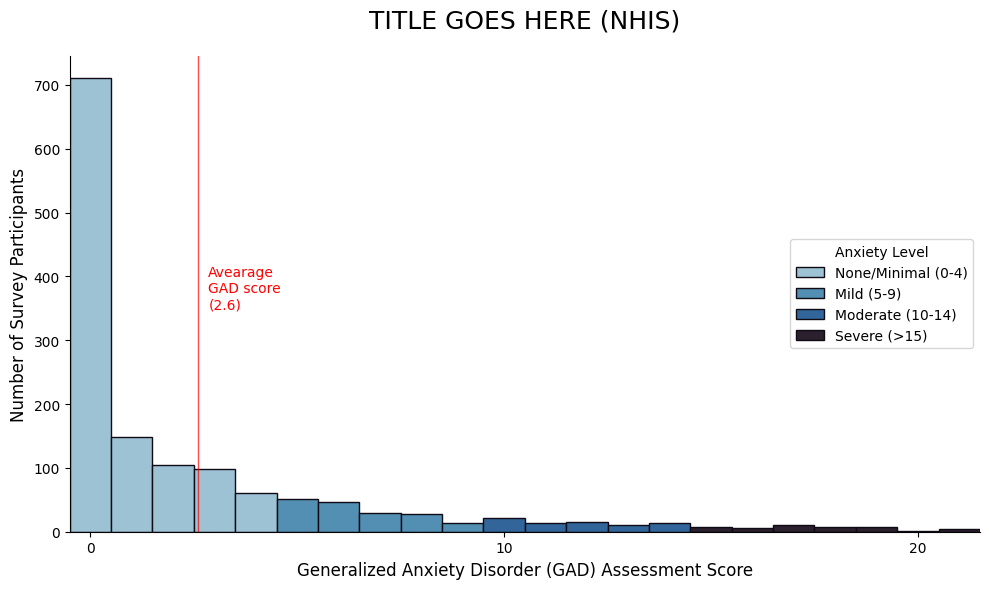

In [107]:
display_GAD_countplot(nhis_GAD_scores_result, 350, 'TITLE GOES HERE (NHIS)')

### Convert the number of participants to percentage for better comparison on the same plot

## How did the GAD categorizations compare between gamers and the general population?
- Only USA data
- 18-22 years old
- Stacked stem plots?

## How did hours spent gaming impact participant's GAD score/category?
This will use just the gaming data.

## How did gaming platform impact participant's GAD score/category?
- This will use just the gaming data.
- Box plots

# Conclusion(s)